In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

In [65]:
files = glob.glob('/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark/job_new/*')

In [272]:
import pandas as pd
import re

def parse_file(file_path):
    data = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i in range(0, len(lines), 2):
            line1 = lines[i].strip()
            line2 = lines[i+1].strip().split()

            
            # 使用正则表达式解析line1
            match = re.match(r'(\d+) \{(.+)\} (\d+) (\d+) (\d+) ([\d.]+)', line1)
            if match:
                result_size = int(match.group(1))
                mat_key = match.group(2).strip()[:-1]
                thread_num = int(match.group(3))
                mat_strat = int(match.group(4))
                queue_thr = int(match.group(5))
                latency = float(match.group(6))
            else:
                continue
            
            map_building_time = float(line2[0])
            materialize_time = float(line2[1])
            sink_hash_join_time = float(line2[2])
            total_latency = float(line2[3])
            io_time = float(line2[4])
            total_latency_2 = float(line2[5])
            
            data.append([result_size, mat_key, thread_num, mat_strat, queue_thr, latency, map_building_time, materialize_time, sink_hash_join_time, total_latency, io_time, total_latency_2])
    
    return pd.DataFrame(data, columns=['result_size', 'key', 'thread_num', 'mat_strat', 'queue_thr', 'latency', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2'])



In [279]:
def draw_pic(query):
    file = f'/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark/job_new/{query}.txt'
    # ff = open(file,'r')
    # lines = [l[:-1] for l in ff.readlines()]
    # with open(f'/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark/job/{query}_.txt','w') as out:
    #     for l in lines:
    #         if 'Error' not in l and 'Fail' not in l:
    #             out.write(l+'\n')
    df = parse_file(file)
    
    print(query)
    data = df[df['result_size'] != 0]
    if len(data)==0:
        return
    grouped_data = data.groupby(['key']).agg({'latency': 'min'}).reset_index()
    grouped_data = pd.merge(grouped_data, data, on=['key', 'latency'], how='left')
    # 绘制柱状图
    keys = grouped_data['key'].unique()
    bar_width = 0.6
    fig, ax = plt.subplots(figsize=(12, 2.8))

    color_map = ['darkblue','skyblue','lightgreen','yellow','gold']
    number_of_keys = []
    for i in range(len(keys)):
        if keys[i]=='(early materialize 0)':
            number_of_keys.append(0)
            continue
        number_of_keys.append(len(keys[i].split(',')))

    zipped_lists = list(zip(number_of_keys, keys))
    sorted_zipped_lists = sorted(zipped_lists, key=lambda x: x[0])
    number_of_keys, keys = zip(*sorted_zipped_lists)
    max_latency = 0
    for i, key in enumerate(keys):
        df_key = grouped_data[grouped_data['key'] == key]
        # print(df_key)
        map_building_time = df_key['map_building_time']
        materialize_time = df_key['materialize_time']
        sink_hash_join_time = df_key['sink_hash_join_time']
        others = df_key['others']
        io_time = df_key['io_time']

        bottom = 0
        ax.bar(i, io_time, bar_width, label='IO Time' if i == 0 else "", color=color_map[0],edgecolor='grey')
        bottom += io_time
        ax.bar(i, others, bar_width, bottom=bottom, label='Others' if i == 0 else "", color=color_map[1],edgecolor='grey')
        bottom += others
        ax.bar(i, sink_hash_join_time, bar_width, bottom=bottom, label='Sink Hash Join Time' if i == 0 else "", color=color_map[2],edgecolor='grey')
        bottom += sink_hash_join_time
        ax.bar(i, materialize_time, bar_width, bottom=bottom, label='Materialize Time' if i == 0 else "", color=color_map[3],edgecolor='grey')
        bottom += materialize_time
        ax.bar(i, map_building_time, bar_width, bottom=bottom, label='Map Building Time' if i == 0 else "", color=color_map[4],edgecolor='grey')

    for i, key in enumerate(keys):
        time = grouped_data[grouped_data['key'] == key]['latency'].iloc[0]
        if time>max_latency:
            max_latency = time
        if key == '(early materialize 0)':
            ax.axhline(y=time, color='grey', linestyle='--')
        else:
            early = grouped_data[(grouped_data['key'] == '(early materialize 0)')]['latency'].iloc[0]
            if time<early:
                enhance = (early - time)/early
                ax.text(i-bar_width/2, time, '%.1f'%(enhance*100.0)+'%')

    key_alias = []
    for i, key in enumerate(keys):
        if key == '(early materialize 0)':
            key_alias.append('em')
            continue
        chosen = key.split(', ')
        tmp_key = []
        for k in chosen:
            # print(k)
            tmp_key.append(k.split(' ')[0][1:].split('.')[1] + k.split(' ')[1][:-1])
        key_alias.append('\n'.join(tmp_key))
    if number_of_keys[-1]>number_of_keys[-2]:
        key_alias[-1] = 'lm'
    ax.set_xlabel('LM Keys')
    ax.set_ylabel('Latency')
    ax.set_title('Query '+query+' time breakdown')
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(key_alias,rotation=20) #rotation=30
    # ax.set_xticklabels(key_alias,rotation=0)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 10)
    ax.set_ylim([0, max_latency*1.05])
    plt.tight_layout()
    plt.show()
    # bars=plt.bar(x=[f"{key}" for key in grouped_data['key']], height=grouped_data['latency'])
    # for bar, (key,  time) in zip(bars, zip(grouped_data['key'], grouped_data['latency'])):
    #     if key == '(early materialize 0),':
    #         bar.set_color('orange')
    #         plt.axhline(y=bar.get_height(), color='grey', linestyle='--')
    #     else:
    #         early = grouped_data[(grouped_data['key'] == '(early materialize 0),')]['latency'].iloc[0]
    #         if time<early:
    #             enhance = (early - time)/early
    #             plt.text(f"{key}", time, '%.3f'%enhance)
            
            
    # plt.xlabel('key')
    # plt.ylabel('Latency')
    # plt.title(query)
    # plt.xticks(rotation=20)
    # plt.tight_layout()
    # plt.show()

33a


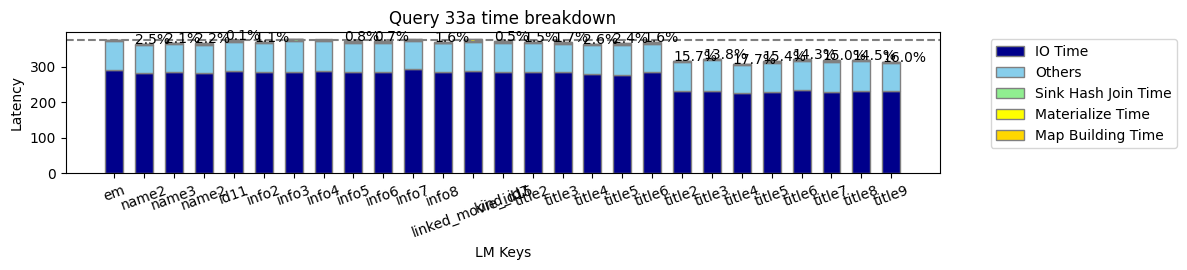

In [283]:
query_name = '33a'
draw_pic(query_name)

In [98]:
def draw_pic(query):
    file = f'/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark/job_new/{query}.txt'
    # print(query)
    # ff = open(file,'r')
    # lines = [l[:-1] for l in ff.readlines()]
    # with open(f'/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark/job/{query}_.txt','w') as out:
    #     for l in lines:
    #         if 'Error' not in l and 'Fail' not in l:
    #             out.write(l+'\n')
    df = parse_file(file)
    
    data = df[df['result_size'] != 0]
    if len(data)==0:
        return
    grouped_data = data.groupby(['key']).agg({'latency': 'min'}).reset_index()
    grouped_data = pd.merge(grouped_data, data, on=['key', 'latency'], how='left')

    keys = grouped_data['key'].unique()
    early = grouped_data[grouped_data['key'] == '(early materialize 0)']
    late = grouped_data[grouped_data['key']!= '(early materialize 0)'].nsmallest(1, 'latency')

    return early,late


In [251]:
def plot_comparison(early, late, queries):
    color_map = ['steelblue','skyblue','lightgreen','yellow','gold']
    early_latency = early['latency']
    late_latency = late['latency']

    enhance = []
    for i in range(len(early_latency)):
        enh = round((early_latency.iloc[i]-late_latency.iloc[i])/early_latency.iloc[i] * 100.0,2)
        enhance.append(enh)


    bar_width = 0.4
    index = range(len(queries)) 
    
    fig, ax = plt.subplots(figsize=(100,12))
    
    # 绘制early柱子
    io_time = early['io_time']
    others = early['others']
    sink_hash_join_time = early['sink_hash_join_time']

    bottom = 0
    index = [i - bar_width for i in index]
    ax.bar(index, io_time, bar_width, label='IO Time', color=color_map[0],edgecolor='grey')
    bottom += io_time
    ax.bar(index, others, bar_width, bottom=bottom, label='Others', color=color_map[1],edgecolor='grey')
    bottom += others
    ax.bar(index, sink_hash_join_time, bar_width, bottom=bottom, label='Sink Hash Join Time' , color=color_map[2],edgecolor='grey')

    
    # 绘制late柱子
    io_time = late['io_time']
    others = late['others']
    sink_hash_join_time = late['sink_hash_join_time']
    materialize_time = late['materialize_time']
    map_building_time = late['map_building_time']
    index = [i+bar_width  for i in index]
    bottom = 0
    ax.bar(index, io_time, bar_width, color=color_map[0],edgecolor='grey')
    bottom += io_time
    ax.bar(index, others, bar_width, bottom=bottom, color=color_map[1],edgecolor='grey')
    bottom += others
    ax.bar(index, sink_hash_join_time, bar_width, bottom=bottom, color=color_map[2],edgecolor='grey')
    bottom += sink_hash_join_time
    ax.bar(index, materialize_time, bar_width, bottom=bottom, label='Materialize Time', color=color_map[3],edgecolor='grey')
    bottom += materialize_time
    ax.bar(index, map_building_time, bar_width, bottom=bottom, label='Map Building Time', color=color_map[4],edgecolor='grey')

    for late, enh, i in zip(late_latency, enhance,index):
        plt.text(i-bar_width, late, '%.1f'%enh+'%', fontsize = 35)
    
    ax.set_xlabel('JOB Query', fontsize = 40)
    ax.set_ylabel('Latency', fontsize = 40)
    ax.set_title('Latency Comparison for Different Queries', fontsize = 40)
    ax.set_xticks([i - bar_width / 2 for i in index])
    ax.set_xticklabels(queries, fontsize = 30)
    ax.set_xlim(-1, len(queries) - 0.5 + bar_width)
    
    ax.legend(fontsize = 35)
    
    plt.tight_layout()
    plt.show()
    return enhance



In [252]:
early_data = []
late_data = []
queries = []

columns=['result_size', 'key', 'thread_num', 'mat_strat', 'queue_thr', 'latency', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2']
files = glob.glob('/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark/job_new/*.txt')
for file in files:
    query_name = file.split('/')[-1].split('.')[0]
    if '_' in query_name:
        continue
    queries.append(query_name)
    early, late = draw_pic(query_name)
    early_data.append(early)
    late_data.append(late)

early_data =  pd.concat(early_data,axis=0)
late_data = pd.concat(late_data,axis=0)
    

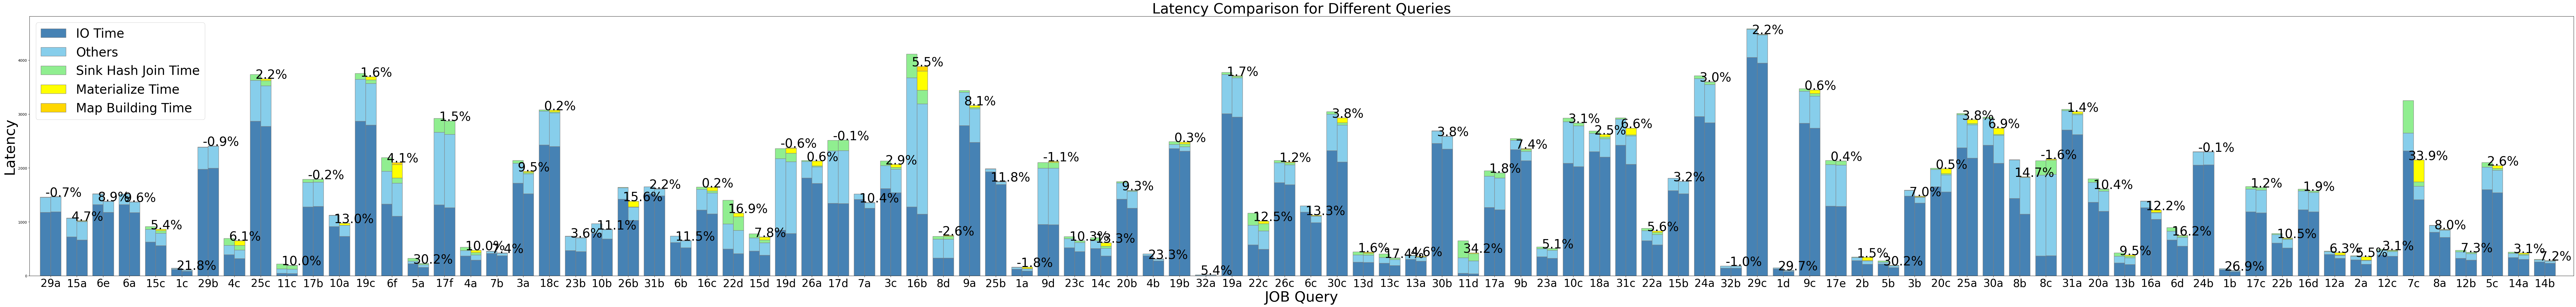

In [253]:
enhance = plot_comparison(early_data,late_data,queries)

In [255]:
sum(enhance)/len(enhance)

np.float64(7.321354166666666)

In [256]:
max(enhance)

np.float64(34.25)

In [257]:
min(enhance)

np.float64(-2.65)

In [268]:
def plot_comparison(early, late, queries):
    color_map = ['steelblue','skyblue','lightgreen','yellow','gold']
    early_latency = early['latency']
    late_latency = late['latency']

    enhance = []
    for i in range(len(early_latency)):
        enh = round((early_latency.iloc[i]-late_latency.iloc[i])/early_latency.iloc[i] * 100.0,2)
        enhance.append(enh)


    bar_width = 0.4
    index = range(len(queries)) 
    
    fig, ax = plt.subplots(figsize=(50,12))
    
    # 绘制early柱子
    io_time = early['io_time']
    others = early['others']
    sink_hash_join_time = early['sink_hash_join_time']

    bottom = 0
    index = [i - bar_width for i in index]
    ax.bar(index, io_time, bar_width, label='IO Time', color=color_map[0],edgecolor='grey')
    bottom += io_time
    ax.bar(index, others, bar_width, bottom=bottom, label='Others', color=color_map[1],edgecolor='grey')
    bottom += others
    ax.bar(index, sink_hash_join_time, bar_width, bottom=bottom, label='Sink Hash Join Time' , color=color_map[2],edgecolor='grey')

    
    # 绘制late柱子
    io_time = late['io_time']
    others = late['others']
    sink_hash_join_time = late['sink_hash_join_time']
    materialize_time = late['materialize_time']
    map_building_time = late['map_building_time']
    index = [i+bar_width  for i in index]
    bottom = 0
    ax.bar(index, io_time, bar_width, color=color_map[0],edgecolor='grey')
    bottom += io_time
    ax.bar(index, others, bar_width, bottom=bottom, color=color_map[1],edgecolor='grey')
    bottom += others
    ax.bar(index, sink_hash_join_time, bar_width, bottom=bottom, color=color_map[2],edgecolor='grey')
    bottom += sink_hash_join_time
    ax.bar(index, materialize_time, bar_width, bottom=bottom, label='Materialize Time', color=color_map[3],edgecolor='grey')
    bottom += materialize_time
    ax.bar(index, map_building_time, bar_width, bottom=bottom, label='Map Building Time', color=color_map[4],edgecolor='grey')

    for late, enh, i in zip(late_latency, enhance,index):
        plt.text(i-bar_width/2, late, '%.1f'%enh+'%', fontsize = 35)
    
    ax.set_xlabel('JOB Query', fontsize = 40)
    ax.set_ylabel('Latency', fontsize = 40)
    ax.set_title('Latency Comparison for Different Queries', fontsize = 40)
    ax.set_xticks([i - bar_width / 2 for i in index])
    ax.set_xticklabels([q[:-1] for q in queries], fontsize = 30)
    ax.set_xlim(-1, len(queries) - 0.5 + bar_width)
    
    ax.legend(fontsize = 35)
    
    plt.tight_layout()
    plt.show()
    return enhance



In [269]:
early_data = []
late_data = []
queries = ['1d','2a','3a','4b','5a','6c','7c','8b','9a','10a','11d','12b','13c','14c','15d','16a','17f','18a','19a','20a',
          '22d','23c','24a','25b','26b','29c','30a','31c','32a']

columns=['result_size', 'key', 'thread_num', 'mat_strat', 'queue_thr', 'latency', 'map_building_time', 'materialize_time', 'sink_hash_join_time', 'others', 'io_time', 'total_latency_2']
files = glob.glob('/home/yihao/duckdb/ht_tmp/duckdb/examples/embedded-c++/release/benchmark/job_new/*.txt')
for query_name in queries:

    # queries.append(query_name)
    early, late = draw_pic(query_name)
    early_data.append(early)
    late_data.append(late)

early_data =  pd.concat(early_data,axis=0)
late_data = pd.concat(late_data,axis=0)
    

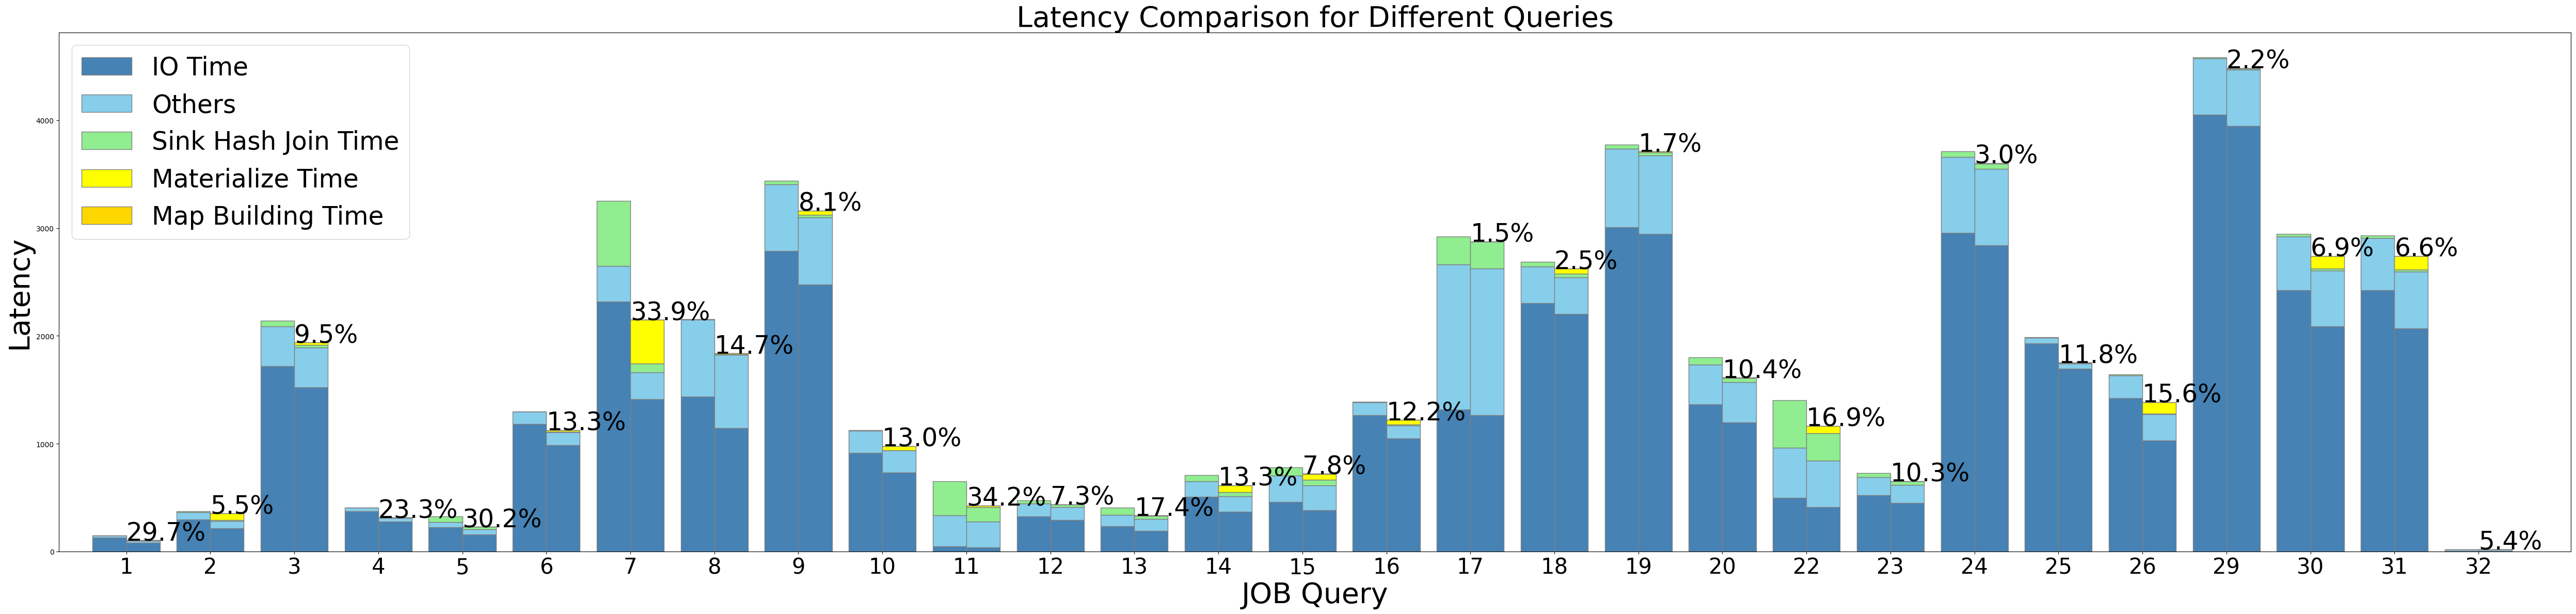

In [270]:
enhance = plot_comparison(early_data,late_data,queries)

In [271]:
sum(enhance)/len(enhance)

np.float64(12.696896551724139)